# Deep Dive

## Part 1: Introduction & Pilot Data
We instead consider data from **two groups**:
- highest level of gene expression
- lowest level of gene expression

We collect pilot data from **N=5** subjects in the two groups.

In [1]:
from scipy.io import loadmat
data = loadmat("pilot_two_group_data.mat")
lo_X = data['low_X']
hi_X = data['high_X']

In [6]:
import scipy.stats as stats
import numpy as np
t_stat, p_value = stats.ttest_ind(lo_X, hi_X, equal_var=True)
print('Low X -> Mean, STD: ', np.mean(lo_X), ',', np.std(lo_X))
print('High X -> Mean, STD:', np.mean(hi_X), ',', np.std(hi_X))
print('Difference in Mean hi X - lo X:', np.mean(hi_X)-np.mean(lo_X))
print('p:', p_value)

Low X -> Mean, STD:  -2.3950062043152864 , 9.47395131954884
High X -> Mean, STD: 11.720002555371144 , 13.642385484595346
Difference in Mean hi X - lo X: 14.11500875968643
p: [0.12762116]


Pilot results support our expectations:
- Lifespan for high gene expression > lifespan for low gene expression
- The difference in mean lifespan between the two groups is about 14 years
- However, this difference is not significant (p=0.128)

**Q:** How many subjects do we need for a sufficiently powered study?

**A:** Let's consider our 3 different paths.

## Path 3A: Resample the pilot data.
- Don't do it!
- N=5 is too small to expect resampling represents the data generating distribution.

## Path 3B: Build a model with the pilot data.
**Model:** Each group is drawn from a normal distribution.

Use the pilot data to estimate model parameters
- standard deviation of each group (can be different), and
- the difference in mean between groups.

Draw data from the model and perform the statistical test for different N.

**Conclusion:** We need about N=12 subjects in each group.

In [7]:
import matplotlib.pyplot as plt

# Estimate model parameters (SD, mean difference) from the pilot data.
lo_SD = np.std(lo_X);
hi_SD = np.std(hi_X);
d     = np.mean(hi_X) - np.mean(lo_X);

alpha = 0.05;

# Evaluate power at different sample sizes
n_list = np.arange(4,30,2)
power  = np.zeros(np.shape(n_list))
for k, N in enumerate(n_list):
    n_k = N

    nSim = 2000;
    rejected = np.full((nSim, 1), False) 
    for i in np.arange(nSim):
        g1 = np.random.randn(n_k,1) * lo_SD             # sample from low
        g2 = np.random.randn(n_k,1) * hi_SD + d         # sample from high
        _, p_value = stats.ttest_ind(g1, g2, equal_var=False) # Do the test
        rejected[i] = p_value < alpha;

    power[k] = np.mean(rejected);
    print(N,power[k])

4 0.2665
6 0.468
8 0.5895
10 0.717
12 0.8005
14 0.8595
16 0.896
18 0.932
20 0.9595
22 0.9745
24 0.984
26 0.9895
28 0.99


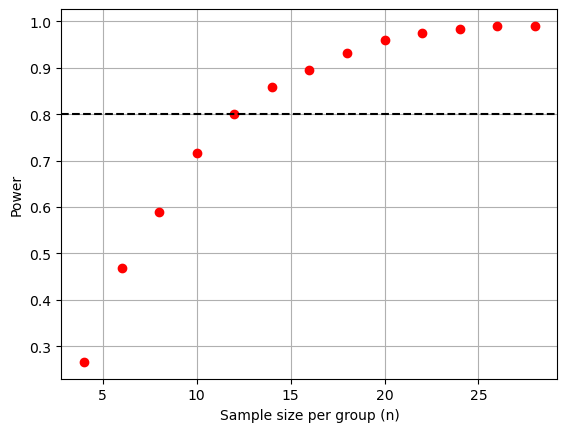

In [8]:
# Plot the results of power versus N.
plt.figure()
plt.plot(n_list, power, 'ro')
plt.grid()
plt.axhline(0.80, color='k', linestyle='--')
plt.xlabel('Sample size per group (n)')
plt.ylabel('Power');

# Path 3C: Build a model without pilot data.
Use our prior knowledge that:
- Data from both groups are drawn from normal distribitions.
- SD=10 years **is the same** for the two groups (i.e., equal variance).
- Difference in mean between the two groups is 12 years.

Compare the power results from sampling the model to the **textbook power formula** from a two-sided two-sample t-test.

**Conclusion:** 
- The textbook formula and model sampling match.
- We need about N=12 subjects in each group.

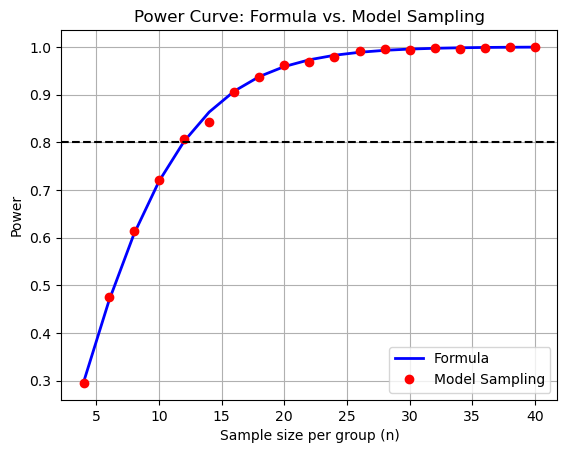

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, nct, ttest_ind

# Parameters
SD = 10
d  = 12
alpha = 0.05

# Sample sizes per group to evaluate
n_list = np.arange(4, 41, 2)

power_parametric_curve = np.zeros(len(n_list))
power_montecarlo_curve = np.zeros(len(n_list))

nSimCurve = 2000
rng = np.random.default_rng()
for k, n_k in enumerate(n_list):
    df_k = 2 * n_k - 2

    # Power for two-sided two-sample t-test
    lam = d / (SD * np.sqrt(2 / n_k))      # Noncentrality parameter
    tcrit = t.ppf(1 - alpha / 2, df_k)     # Two-sided critical t-value
    power_parametric_curve[k] = (1 - nct.cdf(tcrit, df_k, lam) + nct.cdf(-tcrit, df_k, lam))

    # Model estimate
    rejected_k = np.zeros(nSimCurve, dtype=bool)
    for i in range(nSimCurve):
        g1 = rng.normal(loc=0, scale=SD, size=n_k)
        g2 = rng.normal(loc=d, scale=SD, size=n_k)
        _, p = ttest_ind(g1, g2, equal_var=True)
        rejected_k[i] = p < alpha
    power_montecarlo_curve[k] = np.mean(rejected_k)

# Plot
plt.figure()
plt.plot(n_list, power_parametric_curve, 'b-', linewidth=2, label='Formula')
plt.plot(n_list, power_montecarlo_curve, 'ro', markerfacecolor='r', label='Model Sampling')
plt.axhline(0.80, color='k', linestyle='--')
plt.xlabel('Sample size per group (n)')
plt.ylabel('Power')
plt.title('Power Curve: Formula vs. Model Sampling')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()